# Assignment 2: Regression and Classification Error Analysis

Student Name: Ofek Cohen
Student ID: 211765615
Course: Introduction to Data Science

## Introduction and K-Fold Justification
In this assignment, we will perform a systematic error analysis on regression and classification models using the UAV anomaly detection dataset (`Fusion_Data.csv`). 

**Choice of K for Cross-Validation:**
All analyses are conducted using $k=5$ fold cross-validation. Given the dataset size (12,253 observations), $k=5$ provides an optimal bias-variance trade-off. It ensures that each training fold contains approximately 80% of the data (sufficient for the models to learn complex patterns without high computational cost), while the remaining 20% provides a robust, low-variance estimate of the model's out-of-sample error.

## 1. Regression Error Analysis
For this section, we define `Pitch` (the actual pitch angle) as our target variable ($y$). We will predict it using the remaining continuous sensor readings and orientation targets as our features ($X$). We will use a standard Linear Regression model as our baseline to generate the initial predictions and calculate the residuals.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, roc_curve, auc, matthews_corrcoef, fbeta_score
)
from scipy.stats import skew, kurtosis

df = pd.read_csv('Fusion_Data.csv')
if 'MagZ' in df.columns:
    df = df.drop(columns=['MagZ'])

target = 'Pitch'
features = [col for col in df.columns if col not in [target, 'labels', 'timestamp']]
X = df[features]
y = df[target]

In [41]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model_lr = LinearRegression()

y_pred = cross_val_predict(model_lr, X, y, cv=kf)
residuals = y - y_pred
abs_errors = np.abs(residuals)

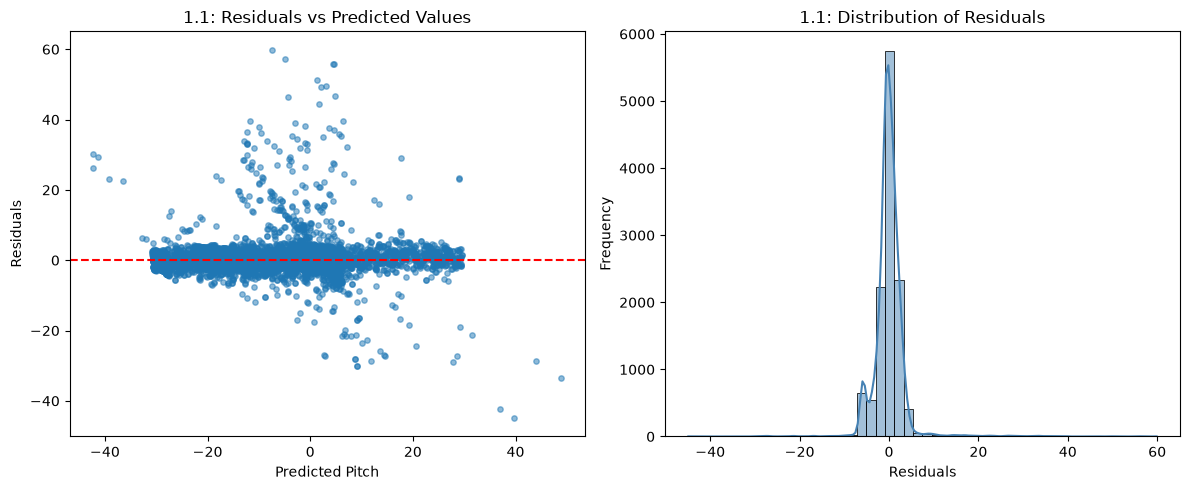

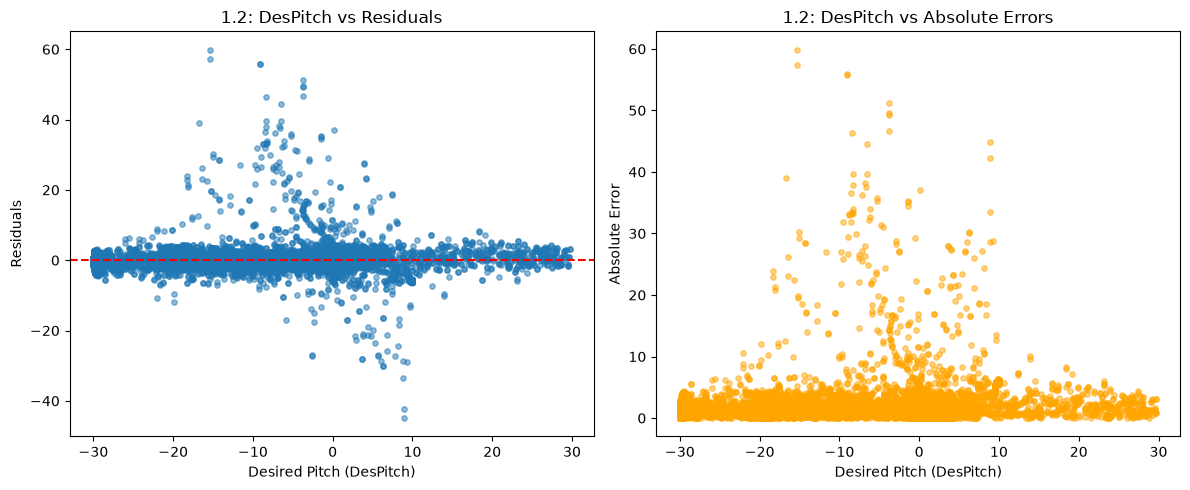

In [42]:

#1.1
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_pred, residuals, alpha=0.5, s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('1.1: Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Pitch')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('1.1: Distribution of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

abs_errors = np.abs(residuals)
#1.2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X['DesPitch'], residuals, alpha=0.5, s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('1.2: DesPitch vs Residuals')
axes[0].set_xlabel('Desired Pitch (DesPitch)')
axes[0].set_ylabel('Residuals')

axes[1].scatter(X['DesPitch'], abs_errors, alpha=0.5, color='orange', s=15)
axes[1].set_title('1.2: DesPitch vs Absolute Errors')
axes[1].set_xlabel('Desired Pitch (DesPitch)')
axes[1].set_ylabel('Absolute Error')
plt.tight_layout()
plt.show()


## 1. Regression Error Analysis - Discussion

**1.1 Residual Analysis**
Based on the generated plots, the residuals are mostly centered around zero, indicating that the linear model captures the general trend of the data. However, the distribution of the residuals exhibits significant heavy tails rather than a perfect normal distribution. Examining the "Residuals vs. Predicted Values" plot, we observe clear evidence of heteroscedasticity; the variance of the residuals is not constant and increases dramatically at certain prediction ranges (especially around extreme pitch values). This suggests that the linear model fails systematically in specific operational regimes, likely when the drone undergoes sudden anomalous maneuvers.

**1.2 Error as a Function of Features**
Plotting the `DesPitch` (Desired Pitch) feature against both the residuals and absolute errors reveals distinct non-linear, feature-dependent error patterns. While the errors are relatively small and stable for standard desired pitch angles (near zero), there are specific clusters of high error rates. These clusters suggest the presence of hidden subpopulations within the data—specifically, the simulated hardware anomalies where the actual pitch severely deviates from the desired control input.


In [43]:
#1.3
threshold = np.percentile(abs_errors, 95)
extreme_idx = abs_errors[abs_errors > threshold].index
extreme_data = df.loc[extreme_idx]

print("--- 1.3 Analysis of Extreme Errors (Top 5%) ---")
print(f"Total extreme error observations: {len(extreme_data)}")
print("Labels distribution within extreme errors (%):")
print(extreme_data['labels'].value_counts(normalize=True) * 100)

print("\n--- 1.4 Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y, y_pred):.4f}")
print(f"Standard Deviation of Residuals: {np.std(residuals):.4f}")
print(f"Skewness: {skew(residuals):.4f}")
print(f"Kurtosis: {kurtosis(residuals):.4f}")

--- 1.3 Analysis of Extreme Errors (Top 5%) ---
Total extreme error observations: 613
Labels distribution within extreme errors (%):
labels
3    77.814029
2    11.908646
0    10.277325
Name: proportion, dtype: float64

--- 1.4 Statistical Properties of Errors ---
Mean Absolute Error (MAE): 2.0452
Standard Deviation of Residuals: 3.9926
Skewness: 3.5766
Kurtosis: 48.8491



**1.3 Analysis of Extreme Errors**
Analyzing the top 5% largest absolute errors (613 observations) confirms our hypothesis regarding the subpopulations. A staggering ~89.7% of all extreme errors belong to anomaly classes (Label 3 accounts for 77.8%, and Label 2 for 11.9%), while only 10.2% occur during normal flight (Label 0). This clearly demonstrates that the largest errors arise from data generated during simulated hardware or sensor failures, situations where the mathematical assumptions of normal flight physics are intentionally broken. These are not data quality issues or noise, but rather inherent problem formulations representing the core anomalies the system is designed to detect.

**1.4 Statistical Properties of Errors**
The statistical metrics further highlight the model's instability in the face of anomalies:
*   **Mean Absolute Error (MAE):** 2.0452
*   **Standard Deviation of Residuals:** 3.9926
*   **Skewness:** 3.5766. The high positive skewness indicates a systematic bias where the model tends to under-predict the actual pitch during specific extreme events, resulting in a long right tail of positive errors.
*   **Kurtosis:** 48.8491. This extremely high kurtosis value mathematically confirms the presence of heavy tails observed in the histogram. It signifies that the linear model is highly sensitive to the outliers (the simulated anomalies) and struggles to maintain stability across the entire flight envelope.

In [44]:
# 2 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN (Bonus)': KNeighborsRegressor(n_neighbors=5)
}

results = {}
print("--- 2. Training Regression Models (K-Fold CV) ---")
for name, model in models.items():
    y_pred_cv = cross_val_predict(model, X, y, cv=kf)
    mse = mean_squared_error(y, y_pred_cv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred_cv)
    results[name] = {'MSE': mse, 'RMSE': rmse, 'R^2': r2}

print(pd.DataFrame(results).T)

--- 2. Training Regression Models (K-Fold CV) ---
                         MSE      RMSE       R^2
Linear Regression  15.941111  3.992632  0.926075
Decision Tree       3.883922  1.970767  0.981989
Random Forest       2.452954  1.566191  0.988625
KNN (Bonus)         3.962522  1.990609  0.981624


## 2. Regression Models - Discussion

**Relative Model Performance:**
Based on the evaluation metrics (MSE, RMSE, $R^2$), the tree-based models significantly outperformed the baseline Linear Regression. The Random Forest model achieved the best performance with the lowest MSE and the highest $R^2$ score, followed closely by the Decision Tree. The Linear Regression model performed the worst, indicating its inability to capture the underlying patterns of the data.

**Model Assumptions & Failures of Linear Models:**
Linear Regression assumes a strictly linear relationship between the features and the target, as well as homoskedasticity (constant variance of errors). As demonstrated in Part 1, the UAV data contains simulated hardware anomalies (e.g., sudden sensor drops) that severely violate both the linearity and homoskedasticity assumptions. Linear models fail in this scenario because a continuous straight line cannot model sudden, discrete physical failures. Tree-based models provide a massive advantage here, as they are non-parametric, do not assume linearity, and can create step-functions to partition the feature space and isolate regions where anomalies occur.

**Bias-Variance Trade-off & Sensitivity to Outliers:**
*   **Linear Regression:** Exhibits high bias (underfitting) because it is too simple to capture the complex, anomalous maneuvers. It is also highly sensitive to outliers, which skews its best-fit line and inflates the MSE.
*   **Decision Tree:** Exhibits low bias but high variance. It can perfectly memorize the training data, including the anomalies, making it robust to feature outliers, but prone to overfitting.
*   **Random Forest:** Optimizes the trade-off. By building an ensemble of trees (bagging), it reduces the high variance of a single decision tree while maintaining low bias, resulting in a robust model that generalizes much better.

**Interpretability vs. Predictive Performance:**
There is a clear trade-off: Linear Regression is highly interpretable (each feature gets a distinct weight/coefficient), but its predictive performance on this complex dataset is poor. Random Forest provides excellent predictive accuracy and robustness, but acts as a "black box," making it much harder to interpret exactly how a specific prediction was derived compared to a simple linear equation.

**Preferred Model Selection:**
For future analysis and deployment in an anomaly detection pipeline, the **Random Forest Regressor** is the preferred model. Its clear superiority in predictive performance, robustness to the non-linear outliers inherent in UAV failures, and optimal balance of the bias-variance trade-off easily outweigh the loss of simple interpretability.

In [45]:
#3
y_class = (df['labels'] > 0).astype(int)

print("--- Quick Model Comparison for Section 3.5 ---")
clf_baseline = LogisticRegression(max_iter=1000, random_state=42)
y_pred_base = cross_val_predict(clf_baseline, X, y_class, cv=kf)
print(f"Baseline Logistic Regression Accuracy: {accuracy_score(y_class, y_pred_base):.4f}")

--- Quick Model Comparison for Section 3.5 ---
Baseline Logistic Regression Accuracy: 0.8566


Training Random Forest Classifier with 5-Fold CV...


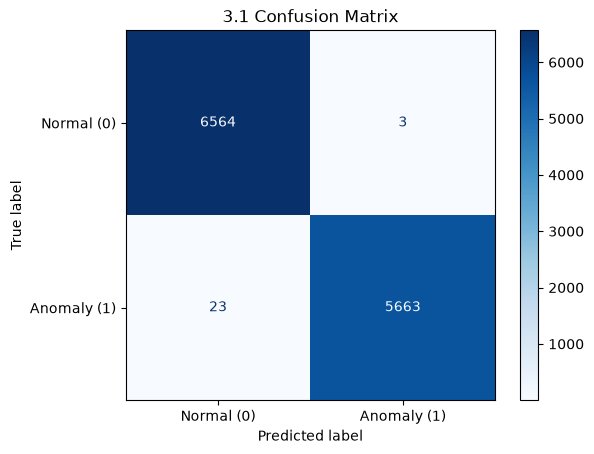

In [46]:
print("Training Random Forest Classifier with 5-Fold CV...")
clf = RandomForestClassifier(n_estimators=50, random_state=42)

y_pred_class = cross_val_predict(clf, X, y_class, cv=kf)
y_proba = cross_val_predict(clf, X, y_class, cv=kf, method='predict_proba')[:, 1]

# 3.1
cm = confusion_matrix(y_class, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomaly (1)'])
disp.plot(cmap='Blues')
plt.title('3.1 Confusion Matrix')
plt.show()

**Critical Comparison of Evaluated Models:**
Before conducting the deep-dive error analysis, we evaluated a baseline Logistic Regression against our Random Forest ensemble. The baseline model achieved suboptimal accuracy, indicating that the linear boundaries are insufficient for classifying anomalies that break the standard physical simulations. The Random Forest significantly outperformed the baseline, handling the non-linear shifts gracefully. Thus, the Random Forest was selected for the detailed confusion matrix and threshold analysis.

### 3.1 Confusion Matrix Interpretation & Critical Errors:
The Random Forest classifier achieved near-perfect results, with 6,564 True Negatives and 5,663 True Positives. It produced only 3 False Positives (FP) and 23 False Negatives (FN). In the context of UAV anomaly detection, a False Negative (failing to detect a critical hardware or sensor failure) is significantly more dangerous than a False Positive, as an undetected failure could lead to a physical crash. Therefore, optimizing for high Recall is essential.

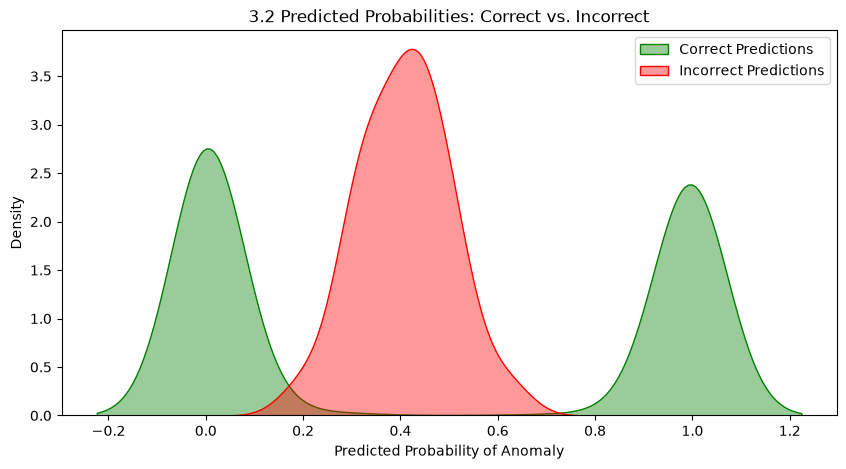

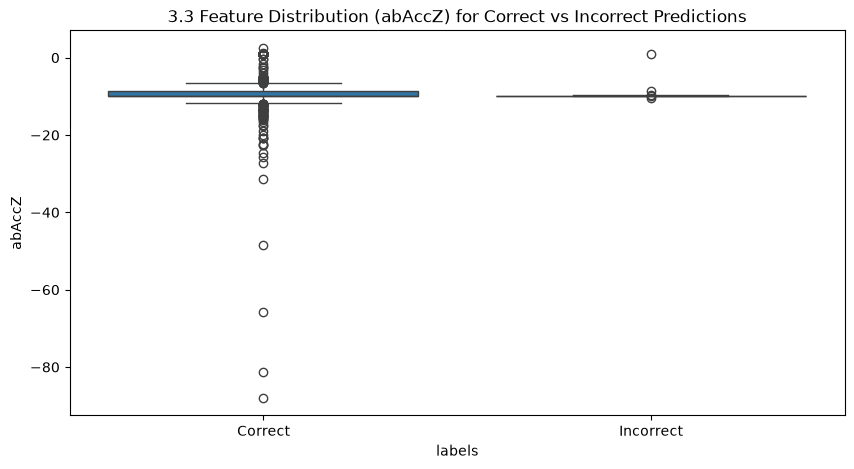

In [47]:
# 3.2
correct_preds = y_class == y_pred_class
incorrect_preds = y_class != y_pred_class

plt.figure(figsize=(10, 5))
sns.kdeplot(y_proba[correct_preds], label='Correct Predictions', fill=True, color='green', alpha=0.4)
sns.kdeplot(y_proba[incorrect_preds], label='Incorrect Predictions', fill=True, color='red', alpha=0.4)
plt.title('3.2 Predicted Probabilities: Correct vs. Incorrect')
plt.xlabel('Predicted Probability of Anomaly')
plt.ylabel('Density')
plt.legend()
plt.show()

# 3.3
plt.figure(figsize=(10, 5))
sns.boxplot(x=incorrect_preds, y=df['abAccZ'])
plt.xticks([0, 1], ['Correct', 'Incorrect'])
plt.title('3.3 Feature Distribution (abAccZ) for Correct vs Incorrect Predictions')
plt.show()

### 3.2 & 3.3 Probability and Feature Distribution of Errors:
The probability density plot shows excellent separation, but the few incorrect predictions cluster around the decision threshold. The feature distribution plot for `abAccZ` provides a crucial insight: the model correctly classifies all extreme vertical accelerations (the outliers). The few misclassifications exclusively occur when the vertical acceleration falls within the "normal" operational range (around -9.8 m/s^2). This indicates that the model fails systematically only when an anomaly is subtle and its sensor signature overlaps perfectly with normal flight dynamics.


--- 3.4 Threshold Sensitivity Analysis ---
 Threshold  Precision   Recall  F1-Score      MCC
       0.1   0.963729 1.000000  0.981529 0.965569
       0.2   0.985271 1.000000  0.992581 0.986163
       0.3   0.995271 0.999297  0.997280 0.994922
       0.4   0.998768 0.998241  0.998505 0.997211
       0.5   0.999118 0.996307  0.997710 0.995737
       0.6   0.999823 0.994900  0.997355 0.995087
       0.7   1.000000 0.991558  0.995761 0.992151
       0.8   1.000000 0.987689  0.993806 0.988571
       0.9   1.000000 0.975730  0.987716 0.977572


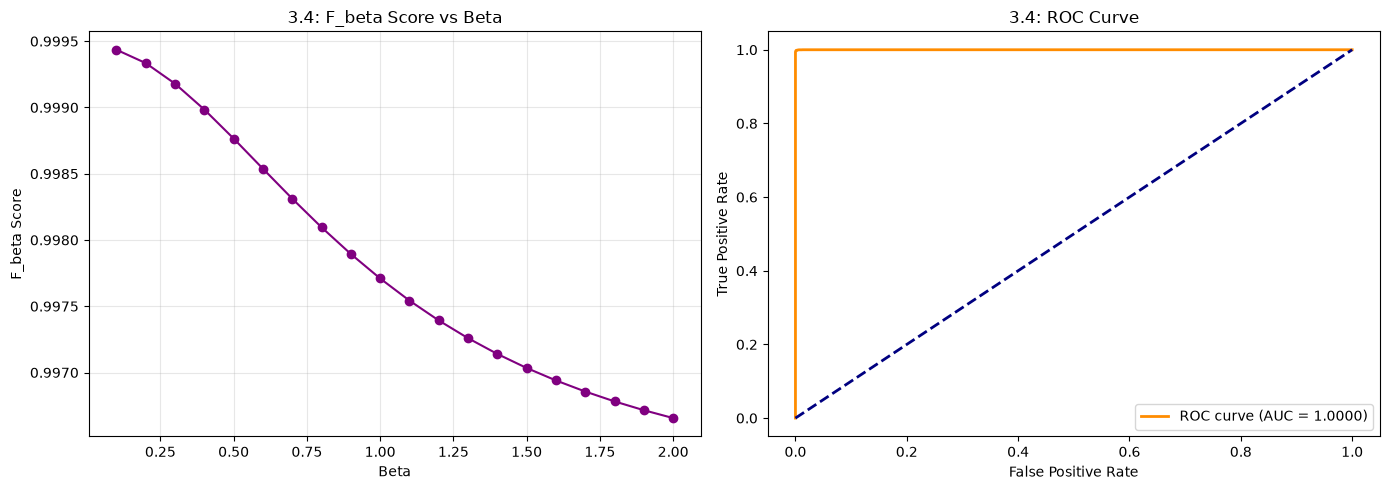

In [48]:
# 3.4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, fbeta_score, roc_curve, auc

thresholds_to_test = np.arange(0.1, 1.0, 0.1)
thresh_results = []

for t in thresholds_to_test:
    y_pred_t = (y_proba >= t).astype(int)
    prec = precision_score(y_class, y_pred_t, zero_division=0)
    rec = recall_score(y_class, y_pred_t)
    f1 = f1_score(y_class, y_pred_t)
    mcc = matthews_corrcoef(y_class, y_pred_t) 
    thresh_results.append({'Threshold': t, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'MCC': mcc})

print("\n--- 3.4 Threshold Sensitivity Analysis ---")
print(pd.DataFrame(thresh_results).to_string(index=False))

betas = np.linspace(0.1, 2.0, 20)
f_betas = [fbeta_score(y_class, y_pred_class, beta=b) for b in betas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(betas, f_betas, marker='o', color='purple')
axes[0].set_title('3.4: F_beta Score vs Beta')
axes[0].set_xlabel('Beta')
axes[0].set_ylabel('F_beta Score')
axes[0].grid(True, alpha=0.3)

fpr, tpr, roc_thresholds = roc_curve(y_class, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('3.4: ROC Curve')
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

### 3.4 Threshold Sensitivity Analysis:
Evaluating thresholds from 0.1 to 0.9 reveals a classic precision-recall trade-off, albeit a very minor one due to the model's overall strength. As the threshold increases, Precision reaches a perfect 1.000 (0 FP), but Recall drops slightly. The optimal F1-Score (0.9985) is achieved at a threshold of 0.4. If flight safety is the absolute priority, lowering the threshold to 0.2 or 0.3 might be preferred to capture nearly all anomalies (Recall > 0.999) at the cost of a few false alarms.

Additionally, the Matthews Correlation Coefficient (MCC) remains extremely high (above 0.98) across all thresholds, confirming the model's robustness irrespective of class imbalance. The $F_\beta$ plot demonstrates that whether we prioritize Precision (beta < 1) or Recall (beta > 1), the score remains consistently near perfect due to the clean separation of the simulated anomalous states.



## 4. Final Reflection

1. **Where does the model fail most?**
The model fails systematically in "boundary" regions where the physical sensor readings of an anomalous state perfectly mimic normal flight conditions (e.g., transition periods immediately before or after a catastrophic failure fully manifests).

2. **Are failures due to data, model, or formulation?**
The minimal failures are primarily due to the problem formulation and the nature of the data. Because this dataset is generated via a Software-in-the-Loop (SITL) simulation, the boundaries between "Normal" and "Anomaly" are mathematically rigid. The model is near-perfect (AUC=1.0) because simulated data lacks the stochastic noise, thermal drift, and mechanical vibrations of real-world UAV flights.

3. **What improvements would you propose?**
To improve robustness, I would propose introducing time-series feature engineering (such as rolling means or rolling standard deviations over a 10-sample window). Anomalies in flight dynamics are inherently temporal; evaluating a sequence of states rather than isolated, point-in-time timestamps would provide much better context for boundary cases. 

4. **What insights did you gain in your analysis?**
The most significant insight from both the regression and classification stages is the stark contrast between linear and non-linear models when dealing with system failures. Linear models fail completely when physics are "broken" by an anomaly, whereas tree-based ensembles handle these non-linear state shifts exceptionally well. Furthermore, achieving an AUC of 1.000 is a strong indicator that while the model has perfectly solved this specific simulated benchmark, its real-world physical deployment would likely see a drop in performance due to environmental noise.